In [27]:
!pip install kaggle
!kaggle datasets download -d sananmuzaffarov/european-football-injuries-2020-2025
!unzip european-football-injuries-2020-2025.zip


Dataset URL: https://www.kaggle.com/datasets/sananmuzaffarov/european-football-injuries-2020-2025
License(s): CC-BY-SA-4.0
european-football-injuries-2020-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  european-football-injuries-2020-2025.zip
replace full_dataset_thesis - 1.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: full_dataset_thesis - 1.csv  


In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv('full_dataset_thesis - 1.csv')

# Basic Labeling/Exploring
print(f"Total Records: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"\nColumns: {df.columns.tolist()}")

#print(df.head())
# Check for the injurt description column
print(f"\nSample injury types: ")
print(df['Injury'].head(20))

# Convert dates to datetime
df['injury_start'] = pd.to_datetime(df['injury_from_parsed'])
df['injury_end'] = pd.to_datetime(df['injury_until_parsed'])

# Calculate duration
df['days_missed'] = (df['injury_end'] - df['injury_start']).dt.days

# Remove invalid entries
df = df[df['days_missed'] >= 0] # negative days = error

# Output Data Stats
print(f"\nDays Missed statistics: ")
print(df['days_missed'].describe())


Total Records: 15603
Total Columns: 11

Columns: ['Season', 'Injury', 'Days', 'Games missed', 'injury_from_parsed', 'injury_until_parsed', 'player_name', 'player_age', 'player_position', 'club', 'league']

Sample injury types: 
0     Syndesmosis ligament tear
1                   Knee injury
2                  Corona virus
3                        bruise
4               Ligament injury
5                       Fitness
6            Torn muscle bundle
7              Hamstring injury
8             Torn muscle fiber
9              Hamstring injury
10                  minor knock
11                Calf problems
12                 Corona virus
13             Hamstring injury
14             Broken nose bone
15                         cold
16            Torn muscle fiber
17         Torn ankle ligaments
18                 Bruised ribs
19               Thigh problems
Name: Injury, dtype: object

Days Missed statistics: 
count    15603.000000
mean        35.102929
std         54.419842
min         

In [29]:
from __future__ import print_function
def classify_severity(days):
  """
  Classify injury severity by days missed
  """
  if days < 7:
    return 'Minor'
  elif days < 21:
    return 'Short-Term'
  elif days < 60:
    return 'Medium-Term'
  elif days < 180:
    return 'Long-Term'
  else:
    return 'Season-Ending'

# Apply Classification
df['severity'] = df['days_missed'].apply(classify_severity)

# Convert to numeric labels for model
severity_mapping = {
    'Minor': 0,
    'Short-Term': 1,
    'Medium-Term': 2,
    'Long-Term': 3,
    'Season-Ending': 4
}
df['severity_'] = df['severity'].map(severity_mapping)

# Check class distribution
print("\nSeverity Distribution:")
print(df['severity'].value_counts())
print("\nClass percentages: ")
print(df['severity'].value_counts(normalize=True) * 100) # Class % Distribution represented w/ decimal


Severity Distribution:
severity
Short-Term       5777
Medium-Term      4613
Minor            2895
Long-Term        1825
Season-Ending     493
Name: count, dtype: int64

Class percentages: 
severity
Short-Term       37.024931
Medium-Term      29.564827
Minor            18.554124
Long-Term        11.696469
Season-Ending     3.159649
Name: proportion, dtype: float64


In [30]:
# Assuming the injury column is named 'Injury'
# Adjust based on actual column name in your dataset

# Remove missing values
df = df[df['Injury'].notna()]

# Clean text (optional - BioBERT handles most cases well)
df['injury_text'] = df['Injury'].str.strip()

# Remove any extremely short descriptions (likely errors)
df = df[df['injury_text'].str.len() > 2]

print(f"\nFinal dataset size: {len(df)} records")
print(f"\nSample injury texts:")
for i, text in enumerate(df['injury_text'].head(10)):
    print(f"{i+1}. {text}")


Final dataset size: 15603 records

Sample injury texts:
1. Syndesmosis ligament tear
2. Knee injury
3. Corona virus
4. bruise
5. Ligament injury
6. Fitness
7. Torn muscle bundle
8. Hamstring injury
9. Torn muscle fiber
10. Hamstring injury


In [31]:
# 1. Reload the data (or use a backup if you made one earlier)
df_full = pd.read_csv('full_dataset_thesis - 1.csv')

# 2. Identify the short ones BEFORE you filter the main dataframe
short_records = df_full[df_full['Injury'].fillna('').str.len() <= 2]
missing_records = df_full[df_full['Injury'].isna()]

# 3. Print them out to inspect
print("--- SHORT DESCRIPTIONS (0-3 chars) ---")
print(short_records['Injury'].unique())

print("\n--- SAMPLE OF DATA THAT WOULD BE REMOVED ---")
print(short_records[['Injury', 'player_name']].head(10))

--- SHORT DESCRIPTIONS (0-3 chars) ---
[]

--- SAMPLE OF DATA THAT WOULD BE REMOVED ---
Empty DataFrame
Columns: [Injury, player_name]
Index: []


In [32]:
# Seperate Datast
# TRAIN / TEST / VALIDATION
# 80/10/10
from sklearn.model_selection import train_test_split

# Create feature and label arrays
X = df['injury_text'].values # Text input
y = df['severity_'].values # Numeric labels (0-4)

# First split: 80% train, 20% temp (10%val + 10%test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,      # 20% for val+test
    random_state=42,
    stratify=y    # Maintain class distribution
)

# Second split:
X_val, X_test, y_val, y_test = train_test_split(
     X_temp, y_temp,
    test_size=0.5,      # 50% of 20% for 10% of total
    random_state=42,
    stratify=y_temp     # Maintain class distribution
)


# Verify total percentages
total_samples = len(X)
print(f"Total Samples: {total_samples}")
print(f"Train Samples: {len(X_train)} samples ({len(X_train)/total_samples*100:.1f}%)")
print(f"Validation Samples: {len(X_val)} samples ({len(X_val)/total_samples*100:.1f}%)")
print(f"Test Samples: {len(X_test)} samples ({len(X_test)/total_samples*100:.1f}%)")

# Check class distribution in each split
print("\n" + "-"*60)
print("CLASS DISTRIBUTION ACROSS SPLITS")
print("="*60)

severity_names = ['Minor', 'Short-Term', 'Medium-Term', 'Long-Term', 'Season-Ending']

for split_name, split_labels in [('Training ', y_train), ('Validation ', y_val), ('Test ', y_test)]:
    print(f"\n{split_name} set distribution:")
    unique, counts = np.unique(split_labels, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"{severity_names[label]}: {count} samples ({count/len(split_labels)*100:5.1f}%)")



Total Samples: 15603
Train Samples: 12482 samples (80.0%)
Validation Samples: 1560 samples (10.0%)
Test Samples: 1561 samples (10.0%)

------------------------------------------------------------
CLASS DISTRIBUTION ACROSS SPLITS

Training  set distribution:
Minor: 2316 samples ( 18.6%)
Short-Term: 4622 samples ( 37.0%)
Medium-Term: 3690 samples ( 29.6%)
Long-Term: 1460 samples ( 11.7%)
Season-Ending: 394 samples (  3.2%)

Validation  set distribution:
Minor: 289 samples ( 18.5%)
Short-Term: 577 samples ( 37.0%)
Medium-Term: 461 samples ( 29.6%)
Long-Term: 183 samples ( 11.7%)
Season-Ending: 50 samples (  3.2%)

Test  set distribution:
Minor: 290 samples ( 18.6%)
Short-Term: 578 samples ( 37.0%)
Medium-Term: 462 samples ( 29.6%)
Long-Term: 182 samples ( 11.7%)
Season-Ending: 49 samples (  3.1%)


In [33]:
# TOKENIZE for BioBERT
from transformers import AutoTokenizer

# Load BioBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('dmis-lab/biobert-v1.1')

# Tokenize all splits
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete!")
print(f"Example tokenized injury:")
print(f"Text: {X_train[0]}")
print(f"Token IDs: {train_encodings['input_ids'][0][:20]}...")  # First 20 tokens



Tokenization complete!
Example tokenized injury:
Text: influenza
Token IDs: [101, 1107, 27206, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


In [34]:
# CREATE DATASET CLASS

import torch

class InjuryDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets
train_dataset = InjuryDataset(train_encodings, y_train)
val_dataset = InjuryDataset(val_encodings, y_val)
test_dataset = InjuryDataset(test_encodings, y_test)

In [35]:
# Load BioBERT Model

from transformers import AutoModelForSequenceClassification

# Load for classification
model = AutoModelForSequenceClassification.from_pretrained(
    'dmis-lab/biobert-v1.1',
    num_labels=5, # 5 severity classes
    problem_type="single_label_classification"
)

# Debug
print(f'Model loaded: {model.__class__.__name__}')
print(f'Number of parameters: {model.num_parameters()}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: BertForSequenceClassification
Number of parameters: 108314117


In [36]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=8,                  # Ceiling; early stopping decides actual length
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",    # Now actually returned by compute_metrics
    greater_is_better=True,              # LINE ADDED
    save_total_limit=2
)

In [37]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    # Weighted = support-weighted (biased toward majority classes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    # Macro = unweighted average across classes — the metric we actually care about
    f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'f1_macro': f1_macro,    # NOW INCLUDED
        'precision': precision,
        'recall': recall
    }

In [38]:
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from transformers import Trainer, EarlyStoppingCallback

# Use sklearn's balanced strategy: n_samples / (n_classes * class_count)
# This produces moderate weights that rebalance without overcorrecting.
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.tensor(class_weights_array, dtype=torch.float)
print(f"Class weights (balanced strategy):")
for name, weight in zip(severity_names, class_weights.tolist()):
    print(f"  {name:<14} {weight:.3f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Trainer with early stopping callback now actually attached
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]   # NOW ATTACHED
)

print("\nStart training...")
trainer.train()
print("\nTraining complete!")

Class weights (balanced strategy):
  Minor          1.078
  Short-Term     0.540
  Medium-Term    0.677
  Long-Term      1.710
  Season-Ending  6.336

Start training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,Precision,Recall
1,1.281164,1.210283,0.392949,0.392756,0.431487,0.472985,0.392949
2,1.249421,1.212682,0.416667,0.398792,0.426226,0.504216,0.416667
3,1.196155,1.188327,0.423077,0.411551,0.444725,0.492706,0.423077
4,1.155644,1.193419,0.424359,0.414775,0.429224,0.468008,0.424359
5,1.174497,1.184654,0.425000,0.431963,0.458512,0.472134,0.425000
6,1.152543,1.183344,0.461538,0.468789,0.482107,0.485682,0.461538
7,1.145015,1.178371,0.425641,0.411823,0.450574,0.485520,0.425641
8,1.151863,1.182990,0.455128,0.458120,0.477445,0.490738,0.455128


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete!


In [39]:
# EVALUATE RESULTS
# Test Set Evaluation

test_results = trainer.evaluate(test_dataset)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
for metric, value in test_results.items():
    print(f"{metric}: {value:.4f}")


TEST SET RESULTS
eval_loss: 1.1963
eval_accuracy: 0.4516
eval_f1: 0.4552
eval_f1_macro: 0.4770
eval_precision: 0.4684
eval_recall: 0.4516
eval_runtime: 1.5247
eval_samples_per_second: 1023.7760
eval_steps_per_second: 16.3960
epoch: 8.0000


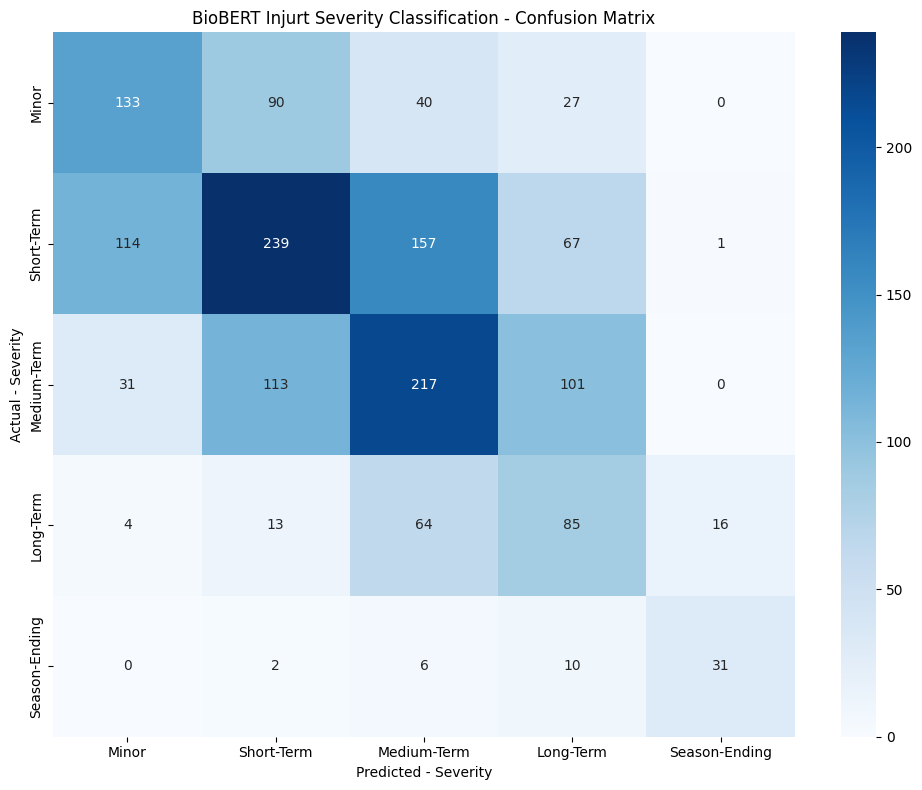


CLASSIFICATION REPORT
               precision    recall  f1-score   support

        Minor       0.47      0.46      0.47       290
   Short-Term       0.52      0.41      0.46       578
  Medium-Term       0.45      0.47      0.46       462
    Long-Term       0.29      0.47      0.36       182
Season-Ending       0.65      0.63      0.64        49

     accuracy                           0.45      1561
    macro avg       0.48      0.49      0.48      1561
 weighted avg       0.47      0.45      0.46      1561



In [40]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=severity_names,
    yticklabels=severity_names
    )
plt.title('BioBERT Injurt Severity Classification - Confusion Matrix')
plt.xlabel('Predicted - Severity')
plt.ylabel('Actual - Severity')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Classification report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=severity_names))

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, confusion_matrix, classification_report,
)
from sklearn.preprocessing import label_binarize

# Pull predictions from the already-trained model
predictions = trainer.predict(test_dataset)
logits = predictions.predictions          # shape: (n_test, 5)
y_true = predictions.label_ids            # shape: (n_test,)
y_probs = softmax(logits, axis=-1)        # shape: (n_test, 5) — rows sum to 1
y_pred_default = logits.argmax(axis=-1)   # default argmax decision

n_classes = 5
class_names = ['Minor', 'Short-Term', 'Medium-Term', 'Long-Term', 'Season-Ending']

# Sanity checks
print(f"Logits shape: {logits.shape}")
print(f"Probabilities sum to ~1 per row: {np.allclose(y_probs.sum(axis=1), 1.0)}")
print(f"\nTest set class distribution:")
for i, name in enumerate(class_names):
    n = (y_true == i).sum()
    print(f"  {name:<15} n = {n:4d} ({n/len(y_true)*100:5.1f}%)")

Logits shape: (1561, 5)
Probabilities sum to ~1 per row: True

Test set class distribution:
  Minor           n =  290 ( 18.6%)
  Short-Term      n =  578 ( 37.0%)
  Medium-Term     n =  462 ( 29.6%)
  Long-Term       n =  182 ( 11.7%)
  Season-Ending   n =   49 (  3.1%)


In [42]:
auc_macro_ovr    = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
auc_weighted_ovr = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
auc_micro_ovr    = roc_auc_score(
    label_binarize(y_true, classes=list(range(n_classes))).ravel(),
    y_probs.ravel()
)
auc_macro_ovo    = roc_auc_score(y_true, y_probs, multi_class='ovo', average='macro')
auc_weighted_ovo = roc_auc_score(y_true, y_probs, multi_class='ovo', average='weighted')

print("="*60)
print("MULTI-CLASS AUC SUMMARY")
print("="*60)
print(f"  Macro    OvR AUC : {auc_macro_ovr:.4f}")
print(f"  Weighted OvR AUC : {auc_weighted_ovr:.4f}")
print(f"  Micro    OvR AUC : {auc_micro_ovr:.4f}")
print(f"  Macro    OvO AUC : {auc_macro_ovo:.4f}")
print(f"  Weighted OvO AUC : {auc_weighted_ovo:.4f}")
print("="*60)
print("\nReference points:")
print("  0.50 = random guessing")
print("  0.70 = acceptable separability")
print("  0.80 = good separability")
print("  0.90 = excellent separability")

MULTI-CLASS AUC SUMMARY
  Macro    OvR AUC : 0.7609
  Weighted OvR AUC : 0.7125
  Micro    OvR AUC : 0.7825
  Macro    OvO AUC : 0.7954
  Weighted OvO AUC : 0.7682

Reference points:
  0.50 = random guessing
  0.70 = acceptable separability
  0.80 = good separability
  0.90 = excellent separability


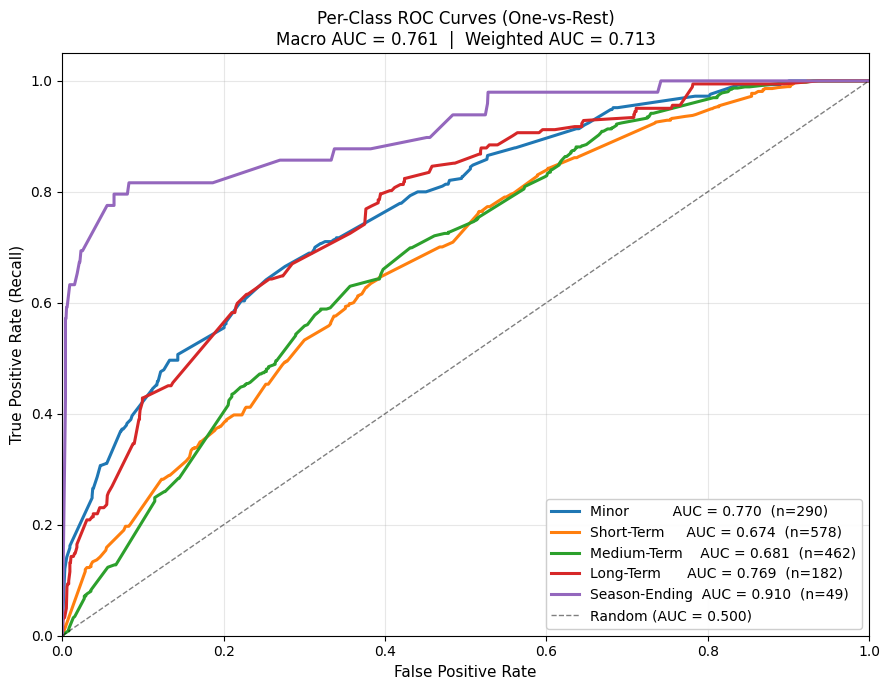


Per-class AUC (sorted, lowest first — worst separability at top):
  Short-Term      AUC = 0.6741
  Medium-Term     AUC = 0.6813
  Long-Term       AUC = 0.7688
  Minor           AUC = 0.7701
  Season-Ending   AUC = 0.9102


In [43]:
# Binarize for OvR
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

# Per-class ROC
fpr, tpr, roc_auc_per_class = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc_per_class[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(9, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, color in zip(range(n_classes), colors):
    n_pos = int(y_true_bin[:, i].sum())
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2.2,
        label=f'{class_names[i]:<14} AUC = {roc_auc_per_class[i]:.3f}  (n={n_pos})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title(
    f'Per-Class ROC Curves (One-vs-Rest)\n'
    f'Macro AUC = {auc_macro_ovr:.3f}  |  Weighted AUC = {auc_weighted_ovr:.3f}',
    fontsize=12
)
plt.legend(loc='lower right', fontsize=10, framealpha=0.95)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

# Tabular summary
print("\nPer-class AUC (sorted, lowest first — worst separability at top):")
ordered = sorted(range(n_classes), key=lambda i: roc_auc_per_class[i])
for i in ordered:
    print(f"  {class_names[i]:<15} AUC = {roc_auc_per_class[i]:.4f}")

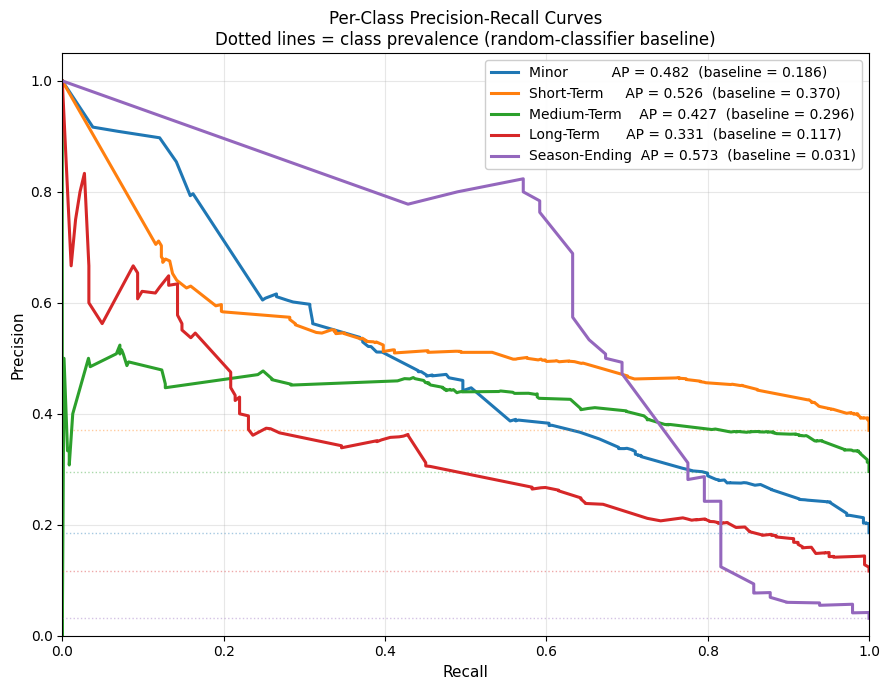


AP / prevalence ratio (how much better than random):
  Minor           AP/prev =  2.60x  (AP=0.482, prev=0.186)
  Short-Term      AP/prev =  1.42x  (AP=0.526, prev=0.370)
  Medium-Term     AP/prev =  1.44x  (AP=0.427, prev=0.296)
  Long-Term       AP/prev =  2.84x  (AP=0.331, prev=0.117)
  Season-Ending   AP/prev = 18.27x  (AP=0.573, prev=0.031)


In [44]:
plt.figure(figsize=(9, 7))
ap_per_class = {}
for i, color in zip(range(n_classes), colors):
    precision_i, recall_i, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap_i = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    ap_per_class[i] = ap_i
    prevalence = y_true_bin[:, i].mean()
    plt.plot(
        recall_i, precision_i, color=color, lw=2.2,
        label=f'{class_names[i]:<14} AP = {ap_i:.3f}  (baseline = {prevalence:.3f})'
    )
    plt.axhline(y=prevalence, color=color, linestyle=':', alpha=0.4, lw=1)

plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=11)
plt.ylabel('Precision', fontsize=11)
plt.title('Per-Class Precision-Recall Curves\nDotted lines = class prevalence (random-classifier baseline)', fontsize=12)
plt.legend(loc='best', fontsize=10, framealpha=0.95)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_per_class.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAP / prevalence ratio (how much better than random):")
for i in range(n_classes):
    prevalence = y_true_bin[:, i].mean()
    lift = ap_per_class[i] / prevalence if prevalence > 0 else float('nan')
    print(f"  {class_names[i]:<15} AP/prev = {lift:5.2f}x  (AP={ap_per_class[i]:.3f}, prev={prevalence:.3f})")

In [45]:
print("="*88)
print("THRESHOLD OPTIMIZATION (per class, one-vs-rest)")
print("="*88)
header = f"{'Class':<15}{'AUC':>7}{'Argmax F1':>12}{'Naive(0.20) F1':>16}{'Best Thresh':>14}{'Best F1':>10}{'Δ vs Argmax':>14}"
print(header)
print("-"*88)

optimal_thresholds = {}
for i in range(n_classes):
    # Argmax F1 (what the model actually does)
    argmax_pred = (y_pred_default == i).astype(int)
    argmax_f1 = f1_score(y_true_bin[:, i], argmax_pred, zero_division=0)

    # Naive 1/K threshold
    naive_pred = (y_probs[:, i] >= 1/n_classes).astype(int)
    naive_f1 = f1_score(y_true_bin[:, i], naive_pred, zero_division=0)

    # Sweep
    thresholds = np.linspace(0.01, 0.99, 99)
    f1_scores = [
        f1_score(y_true_bin[:, i], (y_probs[:, i] >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_idx = int(np.argmax(f1_scores))
    best_t = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    optimal_thresholds[i] = best_t

    delta = best_f1 - argmax_f1
    delta_str = f"+{delta:.3f}" if delta >= 0 else f"{delta:.3f}"

    print(
        f"{class_names[i]:<15}{roc_auc_per_class[i]:>7.3f}{argmax_f1:>12.3f}"
        f"{naive_f1:>16.3f}{best_t:>14.3f}{best_f1:>10.3f}{delta_str:>14}"
    )
print("="*88)

THRESHOLD OPTIMIZATION (per class, one-vs-rest)
Class              AUC   Argmax F1  Naive(0.20) F1   Best Thresh   Best F1   Δ vs Argmax
----------------------------------------------------------------------------------------
Minor            0.770       0.465           0.448         0.310     0.477        +0.012
Short-Term       0.674       0.462           0.578         0.160     0.585        +0.123
Medium-Term      0.681       0.459           0.518         0.180     0.519        +0.061
Long-Term        0.769       0.360           0.324         0.400     0.393        +0.033
Season-Ending    0.910       0.639           0.579         0.900     0.675        +0.036


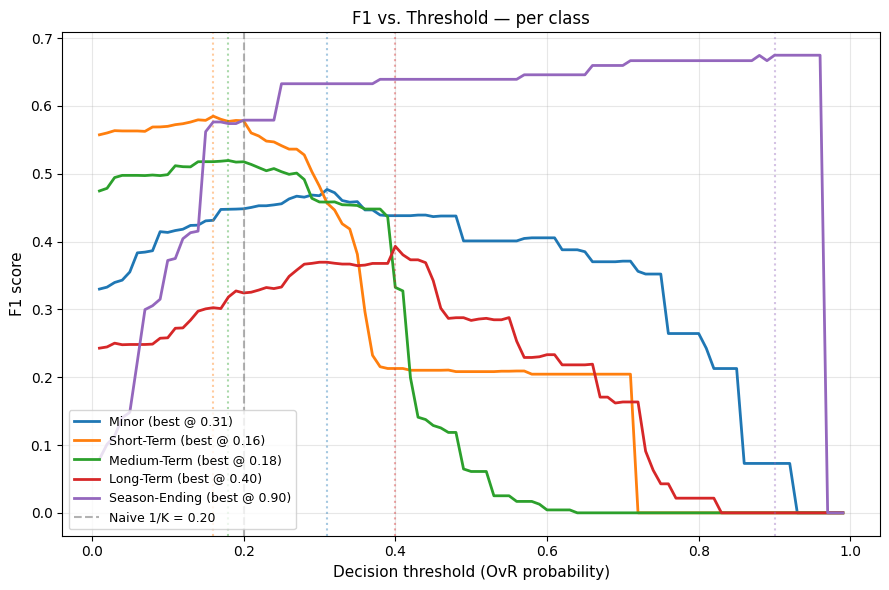

In [46]:
plt.figure(figsize=(9, 6))
thresholds = np.linspace(0.01, 0.99, 99)
for i, color in zip(range(n_classes), colors):
    f1_scores = [
        f1_score(y_true_bin[:, i], (y_probs[:, i] >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    plt.plot(thresholds, f1_scores, color=color, lw=2,
             label=f'{class_names[i]} (best @ {optimal_thresholds[i]:.2f})')
    plt.axvline(optimal_thresholds[i], color=color, linestyle=':', alpha=0.4)

plt.axvline(1/n_classes, color='gray', linestyle='--', alpha=0.6, label=f'Naive 1/K = {1/n_classes:.2f}')
plt.xlabel('Decision threshold (OvR probability)', fontsize=11)
plt.ylabel('F1 score', fontsize=11)
plt.title('F1 vs. Threshold — per class', fontsize=12)
plt.legend(loc='best', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('f1_vs_threshold.png', dpi=300, bbox_inches='tight')
plt.show()

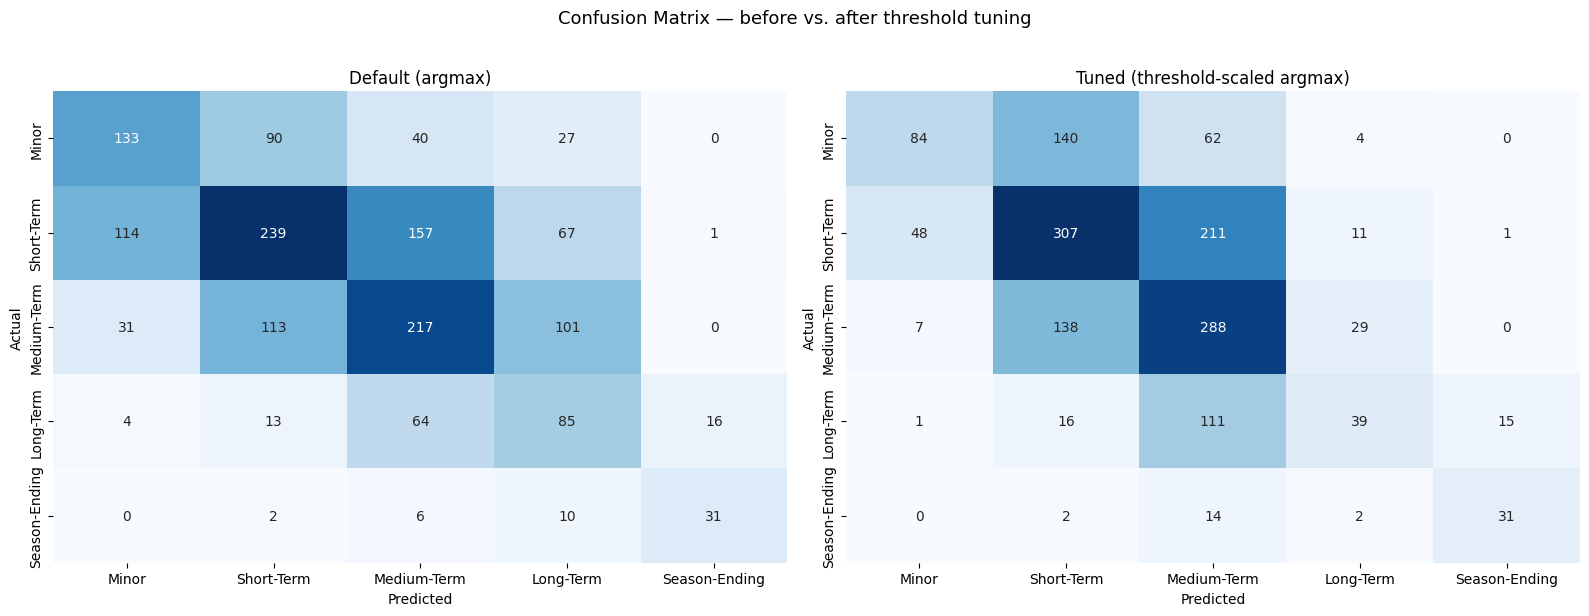


--- DEFAULT (argmax) ---
               precision    recall  f1-score   support

        Minor       0.47      0.46      0.47       290
   Short-Term       0.52      0.41      0.46       578
  Medium-Term       0.45      0.47      0.46       462
    Long-Term       0.29      0.47      0.36       182
Season-Ending       0.65      0.63      0.64        49

     accuracy                           0.45      1561
    macro avg       0.48      0.49      0.48      1561
 weighted avg       0.47      0.45      0.46      1561


--- TUNED (threshold-scaled argmax) ---
               precision    recall  f1-score   support

        Minor       0.60      0.29      0.39       290
   Short-Term       0.51      0.53      0.52       578
  Medium-Term       0.42      0.62      0.50       462
    Long-Term       0.46      0.21      0.29       182
Season-Ending       0.66      0.63      0.65        49

     accuracy                           0.48      1561
    macro avg       0.53      0.46      0.47    

In [47]:
thresh_vec = np.array([optimal_thresholds[i] for i in range(n_classes)])
scaled_probs = y_probs / thresh_vec  # broadcast over class axis
y_pred_tuned = scaled_probs.argmax(axis=-1)

cm_default = confusion_matrix(y_true, y_pred_default)
cm_tuned   = confusion_matrix(y_true, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm, title in zip(
    axes,
    [cm_default, cm_tuned],
    ['Default (argmax)', 'Tuned (threshold-scaled argmax)']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f'{title}', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — before vs. after threshold tuning', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n--- DEFAULT (argmax) ---")
print(classification_report(y_true, y_pred_default, target_names=class_names, zero_division=0))
print("\n--- TUNED (threshold-scaled argmax) ---")
print(classification_report(y_true, y_pred_tuned, target_names=class_names, zero_division=0))

In [48]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from scipy.special import softmax

def compute_metrics(pred):
    """
    Custom metrics for HF Trainer.
    Adds macro/weighted one-vs-rest AUC on top of accuracy/precision/recall/F1.
    AUC is computed from softmaxed logits — threshold-independent.
    """
    labels = pred.label_ids
    logits = pred.predictions
    preds = logits.argmax(axis=-1)
    probs = softmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)

    # AUC requires every class to appear in `labels`. In tiny eval splits a class
    # can be missing — guard against that to avoid crashing the training loop.
    try:
        auc_macro = roc_auc_score(labels, probs, multi_class='ovr', average='macro')
        auc_weighted = roc_auc_score(labels, probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc_macro = float('nan')
        auc_weighted = float('nan')

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc_macro': auc_macro,
        'auc_weighted': auc_weighted,
    }

print("Updated compute_metrics defined.")
print("To use it: re-run training with this function passed into Trainer.")
print("To select best checkpoint by AUC: set metric_for_best_model='auc_macro' in TrainingArguments.")

Updated compute_metrics defined.
To use it: re-run training with this function passed into Trainer.
To select best checkpoint by AUC: set metric_for_best_model='auc_macro' in TrainingArguments.


In [49]:
# ERROR ANALYSIS

# Find misclassified examples
errors = []
for i, (true, pred) in enumerate(zip(y_test, y_pred)):
    if true != pred:
        errors.append({
            'text': X_test[i],
            'true_label': list(severity_mapping.keys())[true],
            'predicted_label': list(severity_mapping.keys())[pred],
            'days_missed': df.iloc[i]['days_missed']
        })
# Show 10 worst errors
print("\n" + "="*50)
print("SAMPLE MISCLASSIFICATIONS")
print("="*50)
for idx, error_data in enumerate(errors[:10]):
    print(f"\n{idx+1}. Injury: {error_data['text']}")
    print(f"   True: {error_data['true_label']} | Predicted: {error_data['predicted_label']}")


SAMPLE MISCLASSIFICATIONS

1. Injury: Ill
   True: Medium-Term | Predicted: Minor

2. Injury: Ligament injury
   True: Minor | Predicted: Long-Term

3. Injury: Knee injury
   True: Medium-Term | Predicted: Long-Term

4. Injury: Calf injury
   True: Short-Term | Predicted: Medium-Term

5. Injury: Syndesmotic ligament tear
   True: Medium-Term | Predicted: Long-Term

6. Injury: Corona virus
   True: Medium-Term | Predicted: Short-Term

7. Injury: Ankle injury
   True: Short-Term | Predicted: Long-Term

8. Injury: Ankle surgery
   True: Medium-Term | Predicted: Long-Term

9. Injury: muscular problems
   True: Minor | Predicted: Short-Term

10. Injury: Hamstring injury
   True: Short-Term | Predicted: Medium-Term


In [50]:
# Save the fine-tuned model
model.save_pretrained('./biobert_injury_classifier')
tokenizer.save_pretrained('./biobert_injury_classifier')

print("Model saved to './biobert_injury_classifier'")

# Save results to CSV
results_df = pd.DataFrame({
    'injury_text': X_test,
    'true_label': [list(severity_mapping.keys())[i] for i in y_test],
    'predicted_label': [list(severity_mapping.keys())[i] for i in y_pred]
})
results_df.to_csv('injury_classification_results.csv', index=False)

print("Results saved to 'injury_classification_results.csv'")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './biobert_injury_classifier'
Results saved to 'injury_classification_results.csv'


In [51]:
# TEST ON NEW INJURIES

def predict_severity(injury_text):
  """
  Predict severity for a new injury description
  """
  # Tokenize
  inputs = tokenizer(
      injury_text,
      return_tensors='pt',
      truncation=True,
      padding=True,
      max_length=128,
  )

  # Get the device of the model
  device = model.parameters().__next__().device

  # Move input tensors to the same device as the model
  inputs = {key: val.to(device) for key, val in inputs.items()}

  # Predict
  model.eval()
  with torch.no_grad():
    outputs = model(**inputs)
    prediction = outputs.logits.argmax(-1).item()

  # Get severity name
  severity_name = list(severity_mapping.keys())[prediction]

  # Get confidence scores
  probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
  # Move probabilities back to CPU for easier printing/handling if needed
  probabilities = probabilities.cpu()

  return severity_name, probabilities

# Test examples
test_injuries = [
    "Hamstring Strain",
    "Anterior Ligament Rupture",
    "Minor Ankle Knock",
    "Fractured Metatarsal"
]

print("\n" + "="*50)
print("PREDICTIONS ON NEW INJURIES")
print("="*50)

for injury in test_injuries:
  severity, confidences = predict_severity(injury)
  print(f"\nInjury: {injury}")
  print(f"Predicted Severity: {severity}")
  print(f"Confidence Scores:")
  for name, prob in zip(severity_names, confidences):
    print(f"{name}: {prob:.2%}")


PREDICTIONS ON NEW INJURIES

Injury: Hamstring Strain
Predicted Severity: Medium-Term
Confidence Scores:
Minor: 5.88%
Short-Term: 25.92%
Medium-Term: 41.14%
Long-Term: 25.16%
Season-Ending: 1.91%

Injury: Anterior Ligament Rupture
Predicted Severity: Long-Term
Confidence Scores:
Minor: 0.28%
Short-Term: 1.05%
Medium-Term: 11.11%
Long-Term: 63.11%
Season-Ending: 24.45%

Injury: Minor Ankle Knock
Predicted Severity: Minor
Confidence Scores:
Minor: 30.07%
Short-Term: 29.54%
Medium-Term: 25.38%
Long-Term: 14.07%
Season-Ending: 0.94%

Injury: Fractured Metatarsal
Predicted Severity: Long-Term
Confidence Scores:
Minor: 1.18%
Short-Term: 3.31%
Medium-Term: 22.73%
Long-Term: 63.71%
Season-Ending: 9.07%
